# NLP Fake News Classifier Model

 Link to dataset : https://www.kaggle.com/datasets/saurabhshahane/fake-news-classification

## Downloading libraries

In [ ]:
# Downloading necessary libraries

!pip install contractions --quiet
!pip install nltk --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.1 MB/s eta 0:00:00


# Downloading dataset

In [ ]:
! gdown --id 1X8QhG9_kkRK8NOX1_zvNT1m83Euu9PYe

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1X8QhG9_kkRK8NOX1_zvNT1m83Euu9PYe
From (redirected): https://drive.google.com/uc?id=1X8QhG9_kkRK8NOX1_zvNT1m83Euu9PYe&confirm=t&uuid=a0f42df7-3ca8-4b30-884d-091d825bf397
To: /content/WELFake_Dataset.csv
100% 245M/245M [00:04<00:00, 49.5MB/s]


##Installing libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from collections import Counter
import contractions  # For expanding contractions like "don't" -> "do not"


# Download required NLTK data
nltk.download('punkt')        # For tokenization
nltk.download('stopwords')    # For stop words
nltk.download('wordnet')      # For lemmatization
nltk.download('punkt_tab')
nltk.download('omw-1.4')

print("All libraries imported and NLTK data downloaded successfully!")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


All libraries imported and NLTK data downloaded successfully!


In [ ]:
import sys
import csv

# Increase the field size limit to the maximum possible integer for your system
max_int = sys.maxsize
while True:
    try:
        csv.field_size_limit(max_int)
        break
    except OverflowError:
        # Decrease the limit if sys.maxsize is too large for the C long type on your platform
        max_int = int(max_int / 10)

# Now you can safely call pd.read_csv()
df = pd.read_csv("/content/WELFake_Dataset.csv")


In [ ]:
df.head()

,Unnamed: 0,title,text,label
0,0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,No comment is expected from Barack Obama Membe...,1
1,1,NaN,Did they post their votes for Hillary already?,1
2,2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,"Now, most of the demonstrators gathered last ...",1
3,3,"Bobby Jindal, raised Hindu, uses story of Chri...",A dozen politically active pastors came here f...,0
4,4,SATAN 2: Russia unvelis an image of its terrif...,"The RS-28 Sarmat missile, dubbed Satan 2, will...",1


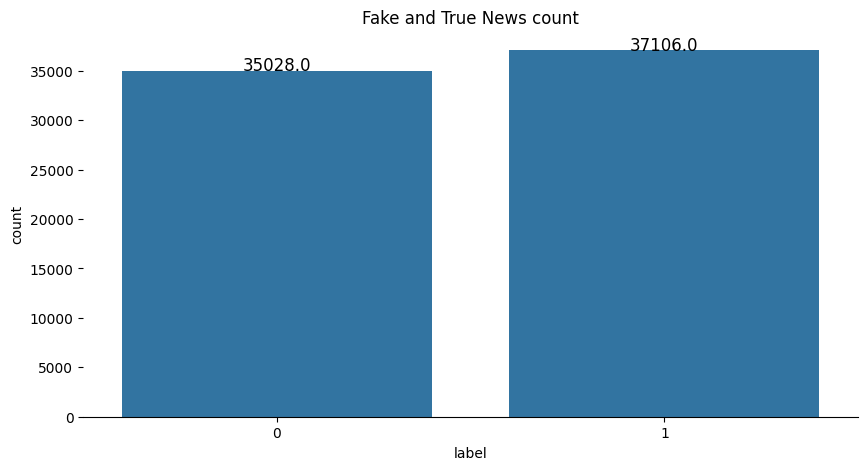

In [ ]:
#creating a count plot for category column
fig = plt.figure(figsize=(10,5))

graph = sns.countplot(x="label", data=df)
plt.title("Fake and True News count")

#removing boundary
graph.spines["right"].set_visible(False)
graph.spines["top"].set_visible(False)
graph.spines["left"].set_visible(False)

#annoting bars with the counts
for p in graph.patches:
        height = p.get_height()
        graph.text(p.get_x()+p.get_width()/2., height + 0.2,height ,ha="center",fontsize=12)

In [ ]:
# Checking if dataset contains any missing values
df.isna().sum()

,0
Unnamed: 0,0
title,558
text,39
label,0


In [ ]:
df.shape

(72134, 4)

In [ ]:
# Remove rows with any missing values
df = df.dropna()

In [ ]:
# Checking if missing values have been removed properly
df.isna().sum()

,0
Unnamed: 0,0
title,0
text,0
label,0


In [ ]:
df.shape

(71537, 4)

In [ ]:
# Checking if the text columns contains any empty strings

mask_empty_strings = (df == '')

rows_with_empty_strings = mask_empty_strings.any(axis=1)

# 3. Get the indices of these rows and convert to a list (array)
indices_array = df[rows_with_empty_strings].index.tolist()

print("\nIndices of rows with empty strings:")
print(len(indices_array))



Indices of rows with empty strings:
0


In [ ]:
#Merging the title and text columns and keeping only the text and label column as only these 2 are required to train the model

df["text"] =df["title"]+ " " + df["text"]

df=df[["text","label"]]

In [ ]:
df.head()

,text,label
0,LAW ENFORCEMENT ON HIGH ALERT Following Threat...,1
2,UNBELIEVABLE! OBAMA’S ATTORNEY GENERAL SAYS MO...,1
3,"Bobby Jindal, raised Hindu, uses story of Chri...",0
4,SATAN 2: Russia unvelis an image of its terrif...,1
5,About Time! Christian Group Sues Amazon and SP...,1


In [ ]:
df.shape

(71537, 2)

## Preprocessing functions

In [ ]:
def expand_contractions(text):
    """
    Expand contractions like "don't" -> "do not", "I'm" -> "I am"
    This must be done BEFORE tokenization to avoid splitting issues
    """
    # Using the 'contractions' library which has a comprehensive mapping
    expanded_text = contractions.fix(text)
    return expanded_text

# Test the function
test_text = "I don't think it's fake news, you shouldn't believe it!"
print("Original:", test_text)
print("Expanded:", expand_contractions(test_text))

Original: I don't think it's fake news, you shouldn't believe it!
Expanded: I do not think it is fake news, you should not believe it!


In [ ]:
def clean_html_urls(text):
    """
    Remove URLs, HTML tags, and HTML entities from text
    These add no semantic value and create noise in the data
    """
    # Remove URLs (http, https, www)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)

    # Remove HTML tags like <br>, <div>, etc.
    text = re.sub(r'<.*?>', '', text)

    # Remove HTML entities like &amp;, &lt;, &gt;
    text = re.sub(r'&[a-z]+;', '', text)

    # Remove extra whitespace created by removals
    text = re.sub(r'\s+', ' ', text).strip()

    return text

# Test the function
test_html = "Check this <a href='http://fake.com'>link</a> for news &amp; updates http://fake.com"
print("Original:", test_html)
print("Cleaned:", clean_html_urls(test_html))

Original: Check this <a href='http://fake.com'>link</a> for news &amp; updates http://fake.com
Cleaned: Check this <a href=' for news updates


In [ ]:
def remove_special_chars(text):
    """
    Remove all special characters and punctuation
    Keep only letters (a-z), numbers (0-9), and spaces
    This helps create clean tokens for processing
    """
    # [^a-zA-Z0-9\s] means: keep a-z, A-Z, 0-9, and whitespace (\s)
    # Remove everything else (punctuation, emojis, special symbols)
    cleaned_text = re.sub(r'[^a-zA-Z0-9\s]', '', text)

    # Remove extra spaces
    cleaned_text = re.sub(r'\s+', ' ', cleaned_text).strip()

    return cleaned_text

# Test the function
test_punct = "Breaking: News!!! This is 100% true? (No, it's fake) #fakenews"
print("Original:", test_punct)
print("Cleaned:", remove_special_chars(test_punct))

Original: Breaking: News!!! This is 100% true? (No, it's fake) #fakenews
Cleaned: Breaking News This is 100 true No its fake fakenews


In [ ]:
def handle_negations(tokens):
    """
    Merge 'not' with the following word to preserve negation meaning
    Example: ['this', 'is', 'not', 'true'] -> ['this', 'is', 'not_true']
    This MUST be done BEFORE stopword removal to prevent 'not' from being deleted
    """
    new_tokens = []
    skip_next = False  # Flag to skip the word that was merged with 'not'

    for i, word in enumerate(tokens):
        if skip_next:
            skip_next = False
            continue

        # If current word is 'not' and there's a next word
        if word == 'not' and i + 1 < len(tokens):
            # Merge 'not' with the next word
            new_tokens.append(f"not_{tokens[i + 1]}")
            skip_next = True  # Skip the next word since it's now merged
        else:
            new_tokens.append(word)

    return new_tokens

# Test the function
test_tokens = ['this', 'is', 'not', 'true', 'news']
print("Original tokens:", test_tokens)
print("After negation handling:", handle_negations(test_tokens))


Original tokens: ['this', 'is', 'not', 'true', 'news']
After negation handling: ['this', 'is', 'not_true', 'news']


In [ ]:
def remove_stopwords(tokens):
    """
    Remove common English stopwords (e.g., 'the', 'a', 'an', 'and')
    These words add little semantic meaning and increase noise
    """
    stop_words = set(stopwords.words('english'))

    # Additional custom stopwords specific to fake news detection
    custom_stopwords = {'said', 'would', 'could', 'also', 'one', 'two', 'get', 'go'}
    stop_words.update(custom_stopwords)

    # Filter out stopwords
    filtered_tokens = [word for word in tokens if word not in stop_words]

    return filtered_tokens

# Test the function
test_tokens2 = ['this', 'is', 'the', 'best', 'and', 'only', 'truth']
print("Original tokens:", test_tokens2)
print("After stopword removal:", remove_stopwords(test_tokens2))

Original tokens: ['this', 'is', 'the', 'best', 'and', 'only', 'truth']
After stopword removal: ['best', 'truth']


In [ ]:
def lemmatize_tokens(tokens):
    """
    Convert words to their base/dictionary form (lemma)
    Example: 'running', 'ran', 'runs' -> 'run'
    This reduces vocabulary size and groups similar meanings
    """
    lemmatizer = WordNetLemmatizer()

    # Lemmatize each token (default is noun, but we can specify 'v' for verbs)
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]

    return lemmatized_tokens

# Test the function
test_tokens3 = ['running', 'ran', 'better', 'mice', 'children']
print("Original tokens:", test_tokens3)
print("After lemmatization:", lemmatize_tokens(test_tokens3))

Original tokens: ['running', 'ran', 'better', 'mice', 'children']
After lemmatization: ['running', 'ran', 'better', 'mouse', 'child']


## Defining preprocessing pipeline

In [ ]:
def preprocess_full_pipeline(text, remove_rare_freq=False, all_texts=None, doc_idx=None):
    """
    Complete preprocessing pipeline with all steps in correct order

    Steps in order:
    1. Lowercase
    2. Expand contractions
    3. Remove HTML/URLs
    4. Remove special characters
    5. Tokenize
    6. Handle negations (CRITICAL: before stopwords)
    7. Remove stopwords
    8. Lemmatize
    9. Join back to string
    """

    # STEP 1: Lowercase
    text = text.lower()

    # STEP 2: Expand contractions (e.g., "don't" -> "do not")
    text = expand_contractions(text)

    # STEP 3: Remove HTML tags and URLs
    text = clean_html_urls(text)

    # STEP 4: Remove special characters and punctuation
    text = remove_special_chars(text)

    # STEP 5: Tokenization
    tokens = word_tokenize(text)

    # STEP 6: Handle negations (BEFORE stopword removal)
    tokens = handle_negations(tokens)

    # STEP 7: Remove stopwords
    tokens = remove_stopwords(tokens)

    # STEP 8: Lemmatization
    tokens = lemmatize_tokens(tokens)

    # STEP 9: Join tokens back into string
    cleaned_text = ' '.join(tokens)

    return cleaned_text

# Test the complete pipeline
sample_text = "BREAKING: <html>This isn't fake news!!! It's 100% true? Check http://fakenews.com"
print("="*50)
print("ORIGINAL TEXT:")
print(sample_text)
print("\n" + "="*50)
print("CLEANED TEXT:")
print(preprocess_full_pipeline(sample_text))
print("="*50)

ORIGINAL TEXT:
BREAKING: <html>This isn't fake news!!! It's 100% true? Check http://fakenews.com

CLEANED TEXT:
breaking not_fake news 100 true check


## Applying pipeline

In [ ]:
# Apply preprocessing to the text column
df['text_cleaned'] = df['text'].apply(preprocess_full_pipeline)

# View results
print("Original first row:")
print(df['text'].iloc[0])
print("\nCleaned first row:")
print(df['text_cleaned'].iloc[0])

Original first row:
LAW ENFORCEMENT ON HIGH ALERT Following Threats Against Cops And Whites On 9-11By #BlackLivesMatter And #FYF911 Terrorists [VIDEO] No comment is expected from Barack Obama Members of the #FYF911 or #FukYoFlag and #BlackLivesMatter movements called for the lynching and hanging of white people and cops. They encouraged others on a radio show Tuesday night to  turn the tide  and kill white people and cops to send a message about the killing of black people in America.One of the F***YoFlag organizers is called  Sunshine.  She has a radio blog show hosted from Texas called,  Sunshine s F***ing Opinion Radio Show. A snapshot of her #FYF911 @LOLatWhiteFear Twitter page at 9:53 p.m. shows that she was urging supporters to  Call now!! #fyf911 tonight we continue to dismantle the illusion of white Below is a SNAPSHOT Twitter Radio Call Invite   #FYF911The radio show aired at 10:00 p.m. eastern standard time.During the show, callers clearly call for  lynching  and  killing  of

## Visualising preprocessing changes

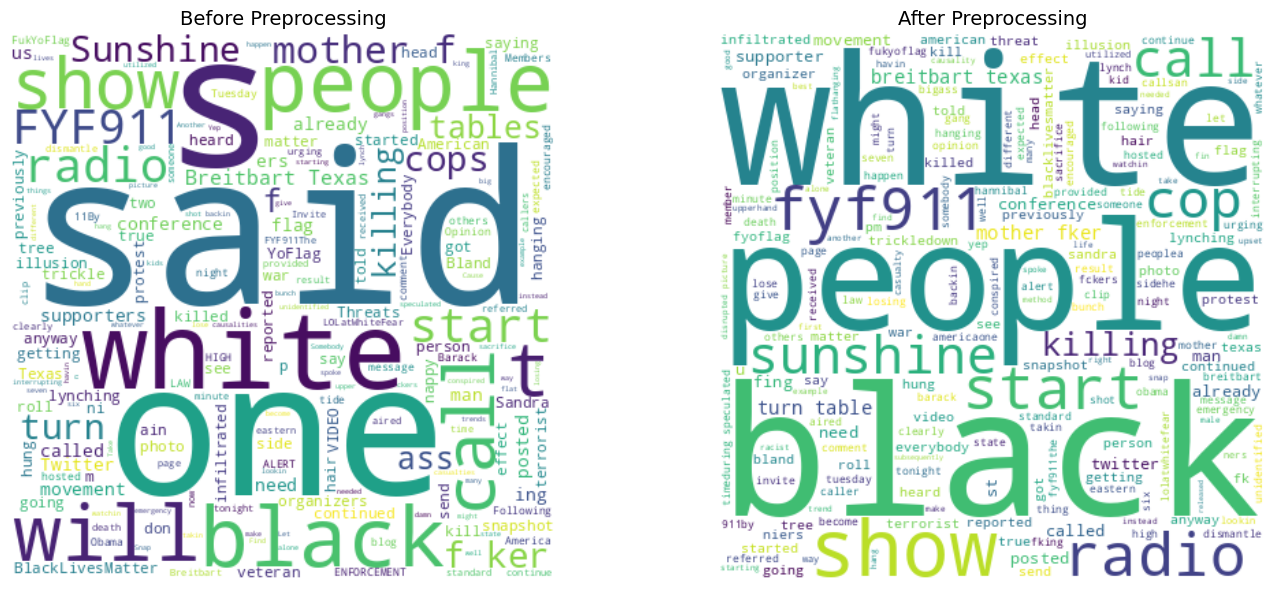

Original vocabulary size: 440
Cleaned vocabulary size: 284
Reduction: 35.45%


In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud

def visualize_preprocessing_impact(original_text, cleaned_text):
    """
    Create side-by-side word clouds to show preprocessing impact
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # Original word cloud
    wordcloud_orig = WordCloud(width=400, height=400, background_color='white').generate(original_text)
    ax1.imshow(wordcloud_orig, interpolation='bilinear')
    ax1.set_title('Before Preprocessing', fontsize=14)
    ax1.axis('off')

    # Cleaned word cloud
    wordcloud_clean = WordCloud(width=400, height=400, background_color='white').generate(cleaned_text)
    ax2.imshow(wordcloud_clean, interpolation='bilinear')
    ax2.set_title('After Preprocessing', fontsize=14)
    ax2.axis('off')

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"Original vocabulary size: {len(set(original_text.split()))}")
    print(f"Cleaned vocabulary size: {len(set(cleaned_text.split()))}")
    print(f"Reduction: {(1 - len(set(cleaned_text.split()))/len(set(original_text.split())))*100:.2f}%")

# Test visualization (uncomment when you have actual data)
visualize_preprocessing_impact(df['text'].iloc[0], df['text_cleaned'].iloc[0])

In [ ]:
# Save your preprocessed dataset for model training
df.to_csv('preprocessed_fake_news_dataset.csv', index=False)
# print("Preprocessed data saved successfully!")

print("\n✅ All preprocessing functions defined and tested!")


✅ All preprocessing functions defined and tested!


## Model training and Evaluation

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import cross_val_score, StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
import warnings
warnings.filterwarnings('ignore')

# Set style for better visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

## Splitting dataset

In [ ]:
X=df["text_cleaned"]
y=df["label"] # Target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"Class distribution in training: {y_train.value_counts().to_dict()}")


Training set size: 57229
Test set size: 14308
Class distribution in training: {1: 29282, 0: 27947}


## Defining Pipeline

In [ ]:
# Configure TfidfVectorizer to NOT re-process your already-cleaned text

def custom_tokenizer(text):
    """ Split on spaces to preserve tokens like 'not_true' """
    return text.split()

# Define multiple models for comparison
models = {
    'Support Vector Machine (SVM)': {
        'model': LinearSVC(random_state=42, max_iter=2000, class_weight='balanced'),
        'params': {}
    },
    'Logistic Regression': {
        'model': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
        'params': {}
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced'),
        'params': {}
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(random_state=42, n_estimators=100),
        'params': {}
    }
}

# Create pipelines for each model
pipelines = {}
for name, config in models.items():
    pipeline = Pipeline([
        ("tfidf", TfidfVectorizer(
            lowercase=False,            # Already preprocessed
            preprocessor=None,          # No extra preprocessing
            tokenizer=custom_tokenizer, # Preserve our tokens
            stop_words=None,            # Already removed
            token_pattern=None,         # Don't use default regex
            ngram_range=(1, 2),         # Unigrams and bigrams
            max_features=15000,         # Limit vocabulary size
            min_df=2,                   # Remove rare terms
            max_df=0.95                 # Remove common terms
        )),
        ("clf", CalibratedClassifierCV(config['model'], cv=5))
    ])
    pipelines[name] = pipeline

print("✅ Models and pipelines defined successfully!")
print(f"Models to train: {list(models.keys())}")

✅ Models and pipelines defined successfully!
Models to train: ['Support Vector Machine (SVM)', 'Logistic Regression', 'Random Forest', 'Gradient Boosting']


## Training different models

In [ ]:
# Store results
results = []
trained_models = {}

print("🔄 Training models...")
print("="*60)

for name, pipeline in pipelines.items():
    print(f"\n📊 Training {name}...")

    # Train the model
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

    # Make predictions
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]  # Probability for positive class

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='binary')
    recall = recall_score(y_test, y_pred, average='binary')
    f1 = f1_score(y_test, y_pred, average='binary')

    # Store results
    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

    print(f"  ✓ Accuracy: {accuracy:.4f}")
    print(f"  ✓ F1-Score: {f1:.4f}")
    print(f"  ✓ Precision: {precision:.4f}")
    print(f"  ✓ Recall: {recall:.4f}")

print("\n" + "="*60)
print("✅ All models trained successfully!")

🔄 Training models...

📊 Training Support Vector Machine (SVM)...
  ✓ Accuracy: 0.9667
  ✓ F1-Score: 0.9671
  ✓ Precision: 0.9631
  ✓ Recall: 0.9712

📊 Training Logistic Regression...
  ✓ Accuracy: 0.9515
  ✓ F1-Score: 0.9522
  ✓ Precision: 0.9488
  ✓ Recall: 0.9556

📊 Training Random Forest...
  ✓ Accuracy: 0.9579
  ✓ F1-Score: 0.9585
  ✓ Precision: 0.9541
  ✓ Recall: 0.9629

📊 Training Gradient Boosting...
  ✓ Accuracy: 0.9463
  ✓ F1-Score: 0.9478
  ✓ Precision: 0.9308
  ✓ Recall: 0.9654

✅ All models trained successfully!


## Training results

📊 Model Performance Comparison:
                       Model  Accuracy  Precision   Recall  F1-Score
Support Vector Machine (SVM)  0.966662   0.963090 0.971219  0.967137
               Random Forest  0.957856   0.954072 0.962917  0.958474
         Logistic Regression  0.951496   0.948757 0.955583  0.952158
           Gradient Boosting  0.946254   0.930763 0.965407  0.947769


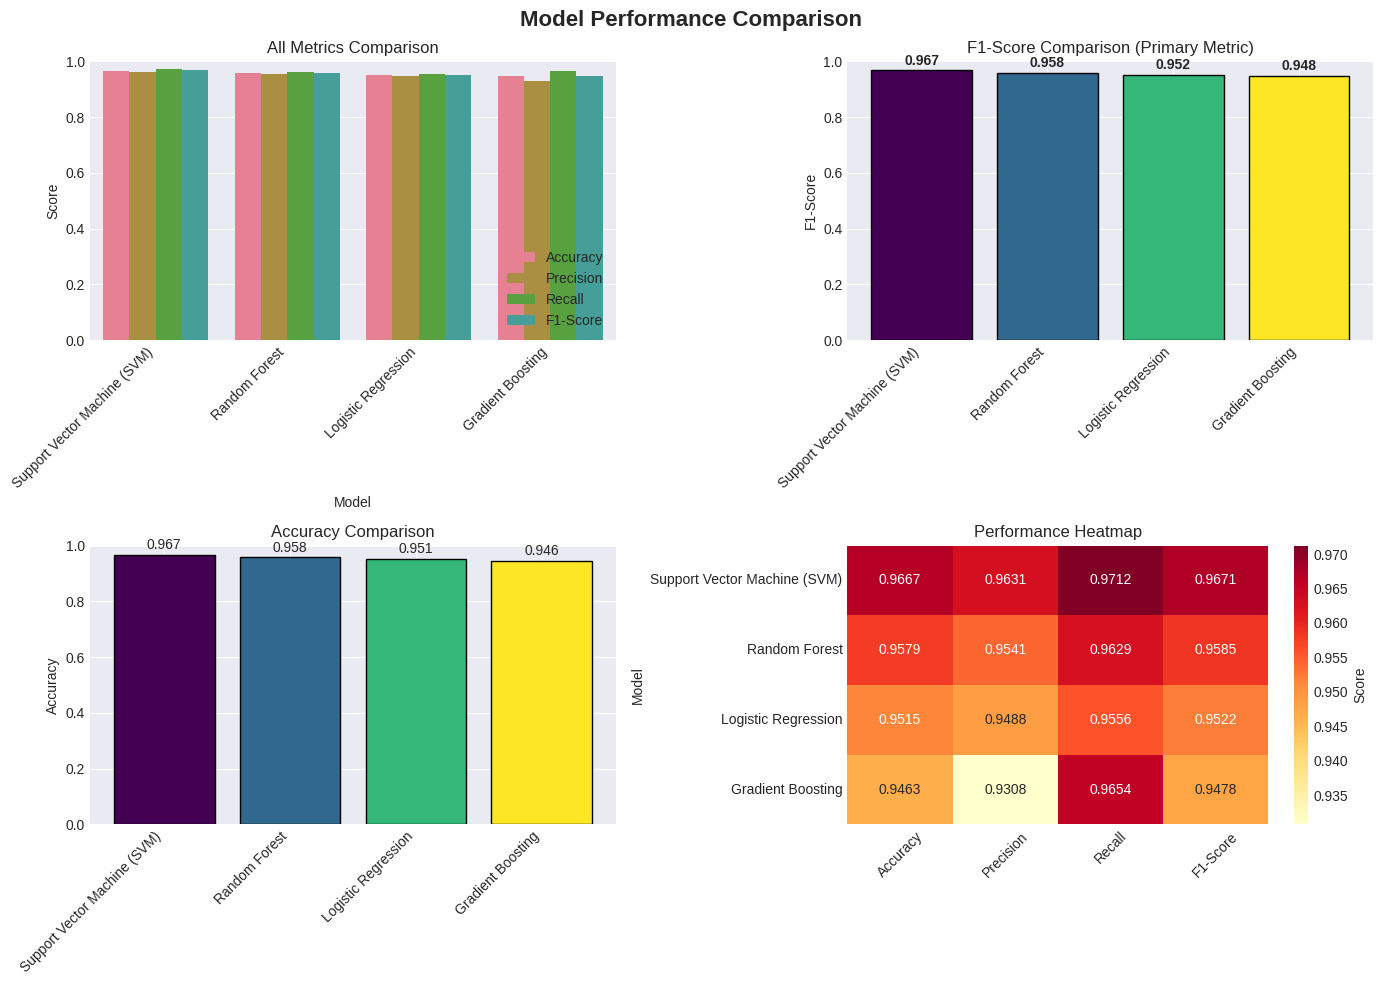


🏆 BEST MODEL: Support Vector Machine (SVM) with F1-Score = 0.9671


In [ ]:
# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('F1-Score', ascending=False)

# Display results table
print("📊 Model Performance Comparison:")
print("="*70)
print(results_df.to_string(index=False))
print("="*70)

# Create comparison visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Model Performance Comparison', fontsize=16, fontweight='bold')

# Bar plot for all metrics
ax1 = axes[0, 0]
results_melted = results_df.melt(id_vars=['Model'], var_name='Metric', value_name='Score')
sns.barplot(data=results_melted, x='Model', y='Score', hue='Metric', ax=ax1)
ax1.set_title('All Metrics Comparison')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right')
ax1.set_ylim([0, 1])
ax1.legend(loc='lower right')

# F1-Score comparison (most important for imbalanced data)
ax2 = axes[0, 1]
colors = plt.cm.viridis(np.linspace(0, 1, len(results_df)))
bars = ax2.bar(results_df['Model'], results_df['F1-Score'], color=colors, edgecolor='black')
ax2.set_title('F1-Score Comparison (Primary Metric)')
ax2.set_ylabel('F1-Score')
ax2.set_ylim([0, 1])
ax2.set_xticklabels(results_df['Model'], rotation=45, ha='right')
# Add value labels on bars
for bar, score in zip(bars, results_df['F1-Score']):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')

# Accuracy comparison
ax3 = axes[1, 0]
bars = ax3.bar(results_df['Model'], results_df['Accuracy'], color=colors, edgecolor='black')
ax3.set_title('Accuracy Comparison')
ax3.set_ylabel('Accuracy')
ax3.set_ylim([0, 1])
ax3.set_xticklabels(results_df['Model'], rotation=45, ha='right')
for bar, score in zip(bars, results_df['Accuracy']):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom')

# Heatmap of all metrics
ax4 = axes[1, 1]
heatmap_data = results_df.set_index('Model')[['Accuracy', 'Precision', 'Recall', 'F1-Score']]
sns.heatmap(heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd', ax=ax4, cbar_kws={'label': 'Score'})
ax4.set_title('Performance Heatmap')
ax4.set_xticklabels(ax4.get_xticklabels(), rotation=45)

plt.tight_layout()
plt.show()

# Identify best model
best_model_name = results_df.iloc[0]['Model']
best_f1_score = results_df.iloc[0]['F1-Score']
print(f"\n🏆 BEST MODEL: {best_model_name} with F1-Score = {best_f1_score:.4f}")

## K-Fold cross validation of best model

🔍 Performing K-Fold Cross Validation on Best Model: Support Vector Machine (SVM)

📊 5-Fold Cross Validation Results:
Individual fold F1-scores: [0.96589827 0.96756955 0.96826728 0.96608197 0.96388398]
Mean F1-Score: 0.9663
Standard Deviation: 0.0015
95% Confidence Interval: [0.9634, 0.9693]


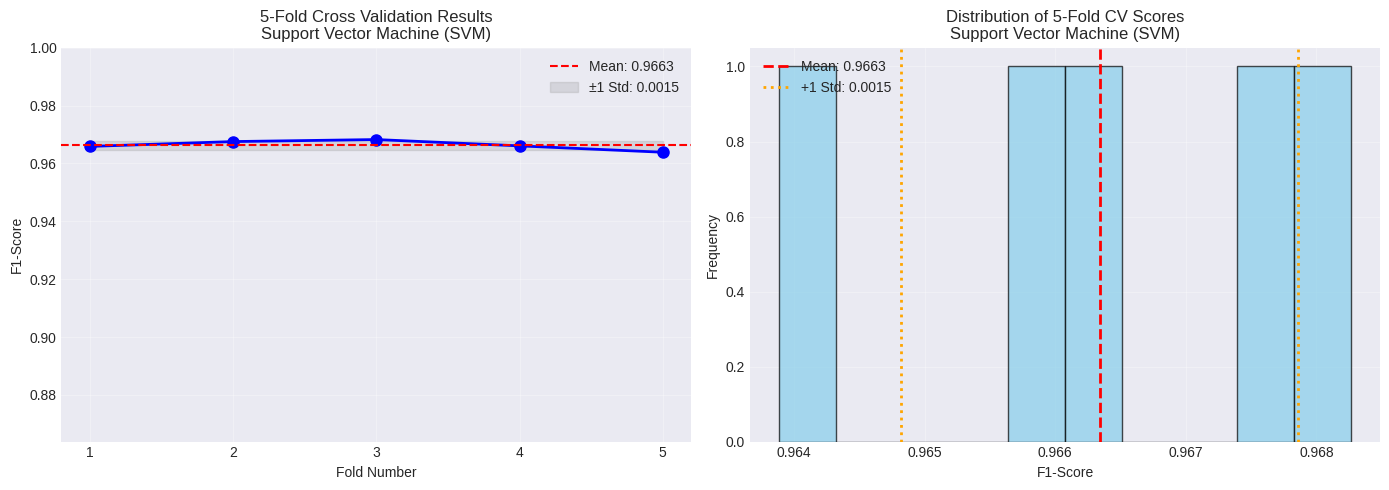

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_pipeline = trained_models[best_model_name]

print(f"🔍 Performing K-Fold Cross Validation on Best Model: {best_model_name}")
print("="*60)

# Define cross-validation strategy
k_folds = 5  # 5-fold cross validation
stratified_kfold = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(
    best_pipeline,
    X_train,  # Use training data for CV
    y_train,
    cv=stratified_kfold,
    scoring='f1_macro',  # Use F1-score for imbalanced data
    n_jobs=-1  # Use all CPU cores
)

# Calculate metrics
print(f"\n📊 {k_folds}-Fold Cross Validation Results:")
print(f"Individual fold F1-scores: {cv_scores}")
print(f"Mean F1-Score: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")
print(f"95% Confidence Interval: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, "
      f"{cv_scores.mean() + 1.96*cv_scores.std():.4f}]")

# Visualization of CV results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Individual fold scores
ax1 = axes[0]
fold_numbers = range(1, k_folds + 1)
ax1.plot(fold_numbers, cv_scores, 'bo-', linewidth=2, markersize=8)
ax1.axhline(y=cv_scores.mean(), color='r', linestyle='--', label=f'Mean: {cv_scores.mean():.4f}')
ax1.fill_between(fold_numbers,
                  cv_scores.mean() - cv_scores.std(),
                  cv_scores.mean() + cv_scores.std(),
                  alpha=0.2, color='gray', label=f'±1 Std: {cv_scores.std():.4f}')
ax1.set_xlabel('Fold Number')
ax1.set_ylabel('F1-Score')
ax1.set_title(f'{k_folds}-Fold Cross Validation Results\n{best_model_name}')
ax1.set_xticks(fold_numbers)
ax1.set_ylim([max(0, cv_scores.min() - 0.1), min(1, cv_scores.max() + 0.1)])
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Distribution of scores
ax2 = axes[1]
ax2.hist(cv_scores, bins=10, edgecolor='black', alpha=0.7, color='skyblue')
ax2.axvline(x=cv_scores.mean(), color='r', linestyle='--', linewidth=2, label=f'Mean: {cv_scores.mean():.4f}')
ax2.axvline(x=cv_scores.mean() + cv_scores.std(), color='orange', linestyle=':', linewidth=2, label=f'+1 Std: {cv_scores.std():.4f}')
ax2.axvline(x=cv_scores.mean() - cv_scores.std(), color='orange', linestyle=':', linewidth=2)
ax2.set_xlabel('F1-Score')
ax2.set_ylabel('Frequency')
ax2.set_title(f'Distribution of {k_folds}-Fold CV Scores\n{best_model_name}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Final model Training and Evaluation

Training Support Vector Machine (SVM) on full training data...

 Final Model Performance on Test Set:
Accuracy:  0.9667
Precision: 0.9631
Recall:    0.9712
F1-Score:  0.9671


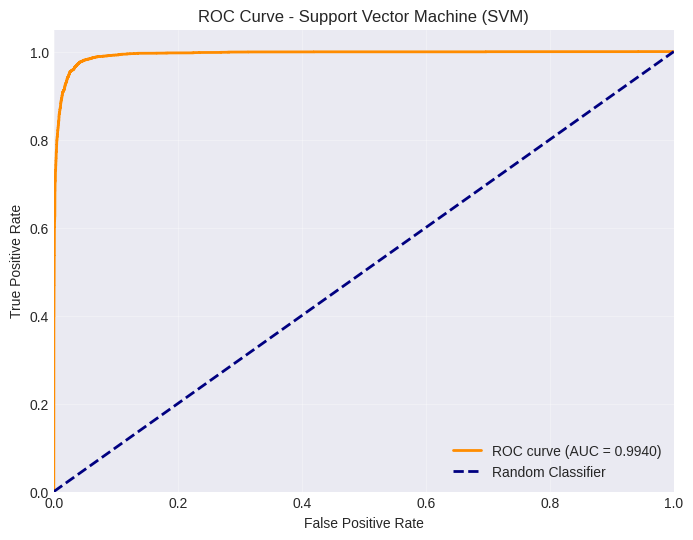


 AUC Score: 0.9940
 Model validation complete!


In [ ]:
print(f"Training {best_model_name} on full training data...")
best_pipeline.fit(X_train, y_train)

# Evaluate on test set
y_pred_test = best_pipeline.predict(X_test)
y_pred_proba_test = best_pipeline.predict_proba(X_test)[:, 1]

# Final metrics
final_accuracy = accuracy_score(y_test, y_pred_test)
final_precision = precision_score(y_test, y_pred_test)
final_recall = recall_score(y_test, y_pred_test)
final_f1 = f1_score(y_test, y_pred_test)

print("\n Final Model Performance on Test Set:")
print("="*50)
print(f"Accuracy:  {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall:    {final_recall:.4f}")
print(f"F1-Score:  {final_f1:.4f}")
print("="*50)

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba_test)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f'ROC Curve - {best_model_name}')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"\n AUC Score: {roc_auc:.4f}")
print(" Model validation complete!")

## Saving model

In [ ]:
import pickle
from google.colab import files

# Save the best model
best_model_filename = f'/content/best_model_{best_model_name.replace(" ", "_")}.pkl'
with open(best_model_filename, 'wb') as file:
    pickle.dump(best_pipeline, file)
print(f" Best model saved to {best_model_filename}")

# Download the model
files.download(best_model_filename)
print(" Model downloaded successfully!")

# Also save the results for report
results_df.to_csv('/content/model_comparison_results.csv', index=False)
print(" Results saved to CSV file")


 Best model saved to /content/best_model_Support_Vector_Machine_(SVM).pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Model downloaded successfully!
 Results saved to CSV file


## Final model summary

In [ ]:
print("\n" + "="*80)
print("📝 FINAL SUMMARY REPORT FOR FAKE NEWS DETECTION")
print("="*80)

print("\n1️⃣ MODEL COMPARISON RESULTS:")
print("-"*40)
for idx, row in results_df.iterrows():
    print(f"   {row['Model']:25s} | F1: {row['F1-Score']:.4f} | Acc: {row['Accuracy']:.4f}")

print(f"\n2️⃣ BEST MODEL SELECTED: {best_model_name}")
print(f"   - F1-Score on test set: {final_f1:.4f}")
print(f"   - Accuracy on test set: {final_accuracy:.4f}")

print(f"\n3️⃣ CROSS-VALIDATION RESULTS (5-fold):")
print(f"   - Mean F1-Score: {cv_scores.mean():.4f}")
print(f"   - Standard Deviation: {cv_scores.std():.4f}")
print(f"   - Model stability: {'Excellent' if cv_scores.std() < 0.02 else 'Good' if cv_scores.std() < 0.05 else 'Moderate'}")

print(f"\n4️⃣ FINAL MODEL PERFORMANCE:")
print(f"   - Precision: {final_precision:.4f} (Ability to avoid false positives)")
print(f"   - Recall: {final_recall:.4f} (Ability to find all fake news)")
print(f"   - AUC Score: {roc_auc:.4f} (Overall discriminative ability)")

print("\n" + "="*80)
print("🎯 RECOMMENDATION:")
if final_f1 > 0.85:
    print("   The model shows EXCELLENT performance and is ready for deployment.")
elif final_f1 > 0.70:
    print("   The model shows GOOD performance. Consider hyperparameter tuning for improvement.")
else:
    print("   The model shows MODERATE performance. Consider feature engineering or more data.")
print("="*80)


📝 FINAL SUMMARY REPORT FOR FAKE NEWS DETECTION

1️⃣ MODEL COMPARISON RESULTS:
----------------------------------------
   Support Vector Machine (SVM) | F1: 0.9671 | Acc: 0.9667
   Random Forest             | F1: 0.9585 | Acc: 0.9579
   Logistic Regression       | F1: 0.9522 | Acc: 0.9515
   Gradient Boosting         | F1: 0.9478 | Acc: 0.9463

2️⃣ BEST MODEL SELECTED: Support Vector Machine (SVM)
   - F1-Score on test set: 0.9671
   - Accuracy on test set: 0.9667

3️⃣ CROSS-VALIDATION RESULTS (5-fold):
   - Mean F1-Score: 0.9663
   - Standard Deviation: 0.0015
   - Model stability: Excellent

4️⃣ FINAL MODEL PERFORMANCE:
   - Precision: 0.9631 (Ability to avoid false positives)
   - Recall: 0.9712 (Ability to find all fake news)
   - AUC Score: 0.9940 (Overall discriminative ability)

🎯 RECOMMENDATION:
   The model shows EXCELLENT performance and is ready for deployment.
